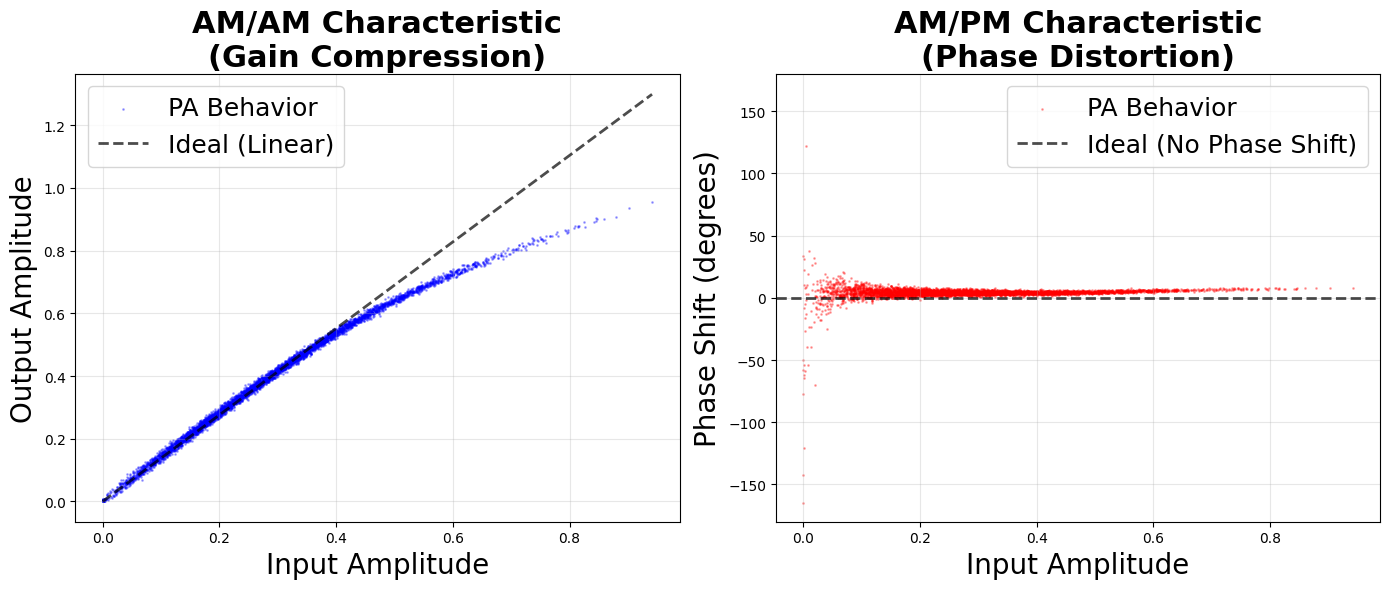


=== PA Characteristic Summary ===
Input amplitude range: 0.0002 to 0.9413
Output amplitude range: 0.0002 to 0.9549
Estimated small-signal gain: 1.3800
Phase distortion range: -837.89° to 122.07°


In [1]:
from sparseDPD import DataManager


simpleDataManager = DataManager(
    filepath='UCD_datasets/PA_IO.mat',
    num_training_points=10000,
    num_validaiton_points=2000,
    num_test_points=2000,
)


simpleDataManager.plot_pa_characteristics()

Using cuda device


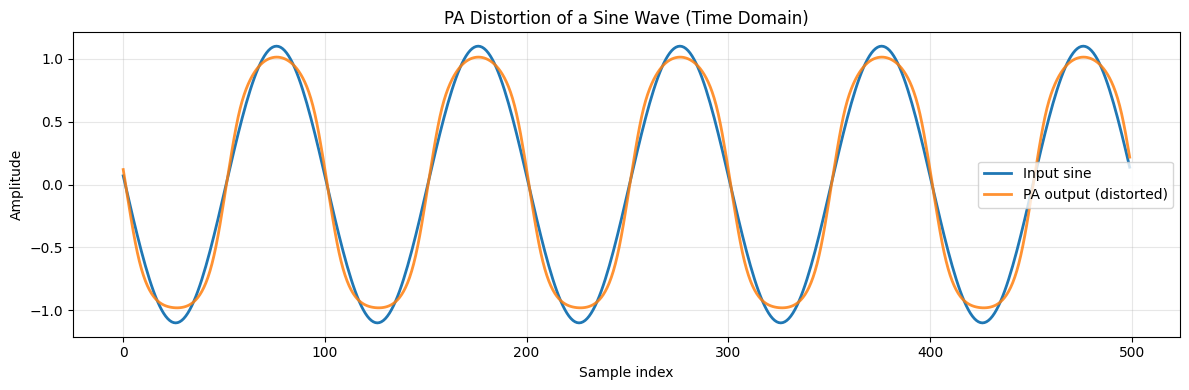

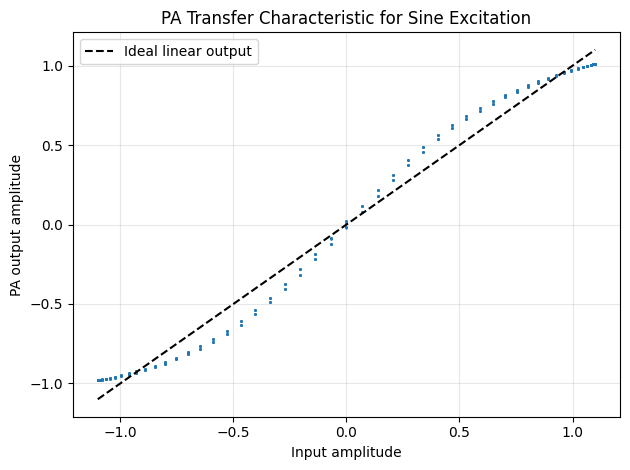

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sparseDPD.PGJANET import PGJANET_NeuralNetwork

# Load pretrained forward PA M
pa_forward = PGJANET_NeuralNetwork(
        nn_file_path='pre_trained_models/pgjanet_checkpoint.pt',
        num_memory_levels=10,
        model_type='PGJANETNetwork',
        forward_model=True,
        seq_len=10,
        seq_stride=1,
        hidden_size=16,
        batch_size=256,
)

# Generate real sine-wave input (baseband, Q=0)
n_samples = 4000
cycles = 40
amplitude = 1.1
n = np.arange(n_samples)
x_real = amplitude * np.sin(2 * np.pi * cycles * n / n_samples)
x = x_real.astype(np.complex128)

# Pass through PA forward ModuleNotFoundError
y = pa_forward.generate_model_output(x)

# Align input length with model output (PGJANET trims seq_len-1 samples)
trim = pa_forward.seq_len - 1
x_aligned = x[trim:]

# Time-domain comparison over a short window
window = 500
t = np.arange(window)

plt.figure(figsize=(12, 4))
plt.plot(t, np.real(x_aligned[:window]), label='Input sine', linewidth=2)
plt.plot(t, np.real(y[:window]), label='PA output (distorted)', linewidth=2, alpha=0.85)
plt.xlabel('Sample index')
plt.ylabel('Amplitude')
plt.title('PA Distortion of a Sine Wave (Time Domain)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Transfer curve: input vs clear_outputplt.figure(figsize=(6, 6))
plt.plot(np.real(x_aligned), np.real(y), '.', markersize=1, alpha=0.25)
lims = [np.min(np.real(x_aligned)), np.max(np.real(x_aligned))]
plt.plot(lims, lims, 'k--', linewidth=1.5, label='Ideal linear output')
plt.xlabel('Input amplitude')
plt.ylabel('PA output amplitude')
plt.title('PA Transfer Characteristic for Sine Excitation')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
